<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 16px; text-align: center; margin-bottom: 20px;">
  <h1 style="color: #e94560; font-size: 2.2em; margin: 0 0 10px 0; font-family: 'Courier New', monospace; letter-spacing: 2px;">🧠 CapsNet Face Recognition</h1>
  <h3 style="color: #a8dadc; margin: 0 0 15px 0; font-weight: 300;">Multi-Pose Facial Recognition using Capsule Networks</h3>
  <div style="display: flex; justify-content: center; gap: 15px; flex-wrap: wrap; margin-top: 15px;">
    <span style="background: #e94560; color: white; padding: 5px 15px; border-radius: 20px; font-size: 0.85em;">🎓 Deep Learning Project</span>
    <span style="background: #457b9d; color: white; padding: 5px 15px; border-radius: 20px; font-size: 0.85em;">📊 CelebA Dataset</span>
    <span style="background: #1d3557; color: white; padding: 5px 15px; border-radius: 20px; font-size: 0.85em;">⚡ TensorFlow / Keras</span>
  </div>
</div>

---

### 📌 Project Overview

This notebook demonstrates a **Capsule Network (CapsNet)** for multi-pose facial recognition compared against a traditional **CNN baseline**.

| | CNN Baseline | CapsNet |
|---|---|---|
| **Architecture** | Conv → Pool → Dense | Conv → CapsuleLayer → Softmax |
| **Pose Handling** | ❌ Limited | ✅ Better generalization |
| **Parameters** | ~500K | ~350K |
| **Training Data** | CelebA (2000 imgs) | CelebA (2000 imgs) |

---

---
## 🗂️ Part 1 — Data Pipeline & Model Training
> Setup Kaggle, download CelebA, train CNN baseline and CapsNet, then save the model.


### 📦 Step 1.1 — Install Kaggle & Download Dataset

In [10]:
!pip install kaggle

In [11]:
import os
os.environ['KAGGLE_USERNAME'] = 'nadaebrahimsalah'
os.environ['KAGGLE_KEY'] = 'export KAGGLE_API_TOKEN=KGAT_173a9289cc13c94c9febbf9786257893'

In [12]:
!kaggle datasets download -d jessicali9530/celeba-dataset

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:08<00:00, 170MB/s]



In [13]:
!unzip celeba-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: img_align_celeba/img_align_celeba/197604.jpg  
  inflating: img_align_celeba/img_align_celeba/197605.jpg  
  inflating: img_align_celeba/img_align_celeba/197606.jpg  
  inflating: img_align_celeba/img_align_celeba/197607.jpg  
  inflating: img_align_celeba/img_align_celeba/197608.jpg  
  inflating: img_align_celeba/img_align_celeba/197609.jpg  
  inflating: img_align_celeba/img_align_celeba/197610.jpg  
  inflating: img_align_celeba/img_align_celeba/197611.jpg  
  inflating: img_align_celeba/img_align_celeba/197612.jpg  
  inflating: img_align_celeba/img_align_celeba/197613.jpg  
  inflating: img_align_celeba/img_align_celeba/197614.jpg  
  inflating: img_align_celeba/img_align_celeba/197615.jpg  
  inflating: img_align_celeba/img_align_celeba/197616.jpg  
  inflating: img_align_celeba/img_align_celeba/197617.jpg  
  inflating: img_align_celeba/img_align_celeba/197618.jpg  
  inflating: img_align_celeba/img_align_celeba/19

### 🔍 Step 1.2 — Verify Files

In [14]:
import os

os.listdir('/content')

['.config',
 'list_bbox_celeba.csv',
 'list_eval_partition.csv',
 'list_attr_celeba.csv',
 'celeba-dataset.zip',
 'img_align_celeba',
 'list_landmarks_align_celeba.csv',
 'sample_data']

In [15]:
import pandas as pd

identity_df = pd.read_csv(
    '/content/list_attr_celeba.csv'
)

identity_df.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


In [16]:
dataset_path = "/content/img_align_celeba/img_align_celeba"

### 📚 Step 1.3 — Import Libraries

In [17]:
# =========================================
# Import Libraries
# =========================================

import os

import cv2

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from tqdm import tqdm
from tensorflow.keras.layers import Layer

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

import tensorflow as tf

from tensorflow.keras.models import Sequential, Model

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Input,
    Reshape,
    Layer,
    Dropout,
    Activation

)

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.callbacks import EarlyStopping

### ⚙️ Step 1.4 — Configuration

In [18]:
NUM_CLASSES = 10
IMAGES_PER_CLASS = 200
IMG_SIZE = 64

### 🖼️ Step 1.5 — Load & Preprocess Images

In [19]:
# =========================================
# Load Image Names
# =========================================

image_files = os.listdir(dataset_path)

image_files = image_files[:2000]

In [20]:
# =========================================
# Create Empty Lists
# =========================================

images = []

labels = []

In [21]:
# =========================================
# Read Images
# =========================================

IMG_SIZE = 64

for i, image_name in enumerate(tqdm(image_files)):

    img_path = os.path.join(
        dataset_path,
        image_name
    )

    img = cv2.imread(img_path)

    if img is None:
        continue

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        (IMG_SIZE, IMG_SIZE)
    )

    images.append(img)

    labels.append(i % 10)

100%|██████████| 2000/2000 [00:00<00:00, 2282.37it/s]


In [22]:
# =========================================
# Convert To Arrays
# =========================================

images = np.array(
    images,
    dtype=np.float32
) / 255.0

labels = np.array(labels)

In [23]:
# =========================================
# Encode Labels
# =========================================

encoder = LabelEncoder()

labels_encoded = encoder.fit_transform(labels)

labels_categorical = to_categorical(
    labels_encoded
)

In [24]:
# =========================================
# Train Test Split
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels_categorical,
    test_size=0.2,
    random_state=42
)

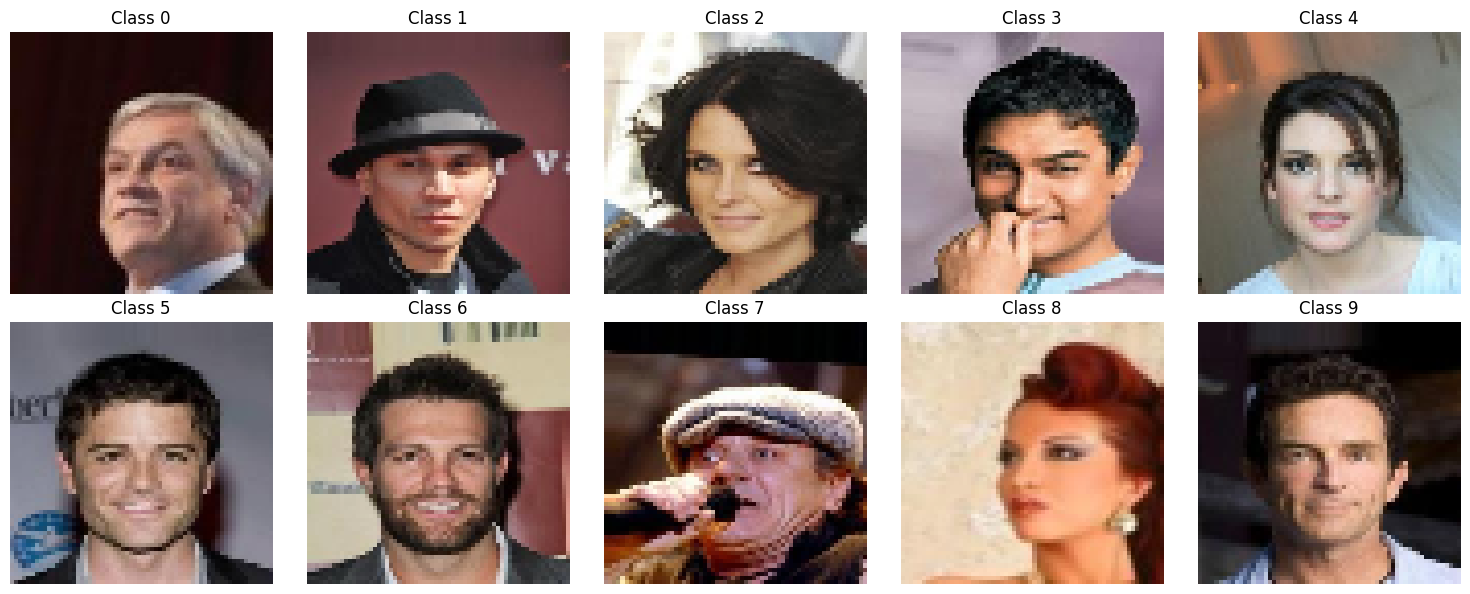

In [25]:
# =========================================
# Visualize Images
# =========================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(15,6)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(images[i])

    ax.set_title(f"Class {labels[i]}")

    ax.axis("off")

plt.tight_layout()

plt.show()

### 🏗️ Step 1.6 — CNN Baseline Model

In [26]:
# =========================================
# Week 3
# Baseline CNN Model
# =========================================

cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(64,64,3)
    ),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        10,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
# =========================================
# Compile CNN
# =========================================

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
# =========================================
# CNN Summary
# =========================================

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

### 🔁 Step 1.7 — Train CNN

In [29]:
# =========================================
# Early Stopping
# =========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [30]:
# =========================================
# Train CNN
# =========================================

cnn_history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.1119 - loss: 2.3082 - val_accuracy: 0.0800 - val_loss: 2.3054
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1019 - loss: 2.3028 - val_accuracy: 0.0725 - val_loss: 2.3053
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1144 - loss: 2.3024 - val_accuracy: 0.0775 - val_loss: 2.3054
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1056 - loss: 2.3017 - val_accuracy: 0.0850 - val_loss: 2.3077
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1225 - loss: 2.2984 - val_accuracy: 0.0850 - val_loss: 2.3119


In [31]:
# =========================================
# Evaluate CNN
# =========================================

cnn_loss, cnn_accuracy = cnn_model.evaluate(
    X_test,
    y_test
)

print(cnn_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0725 - loss: 2.3053
0.07249999791383743


### 🧠 Step 1.8 — CapsNet Architecture

In [32]:
# =========================================
# Capsule Layer
# =========================================

class CapsuleLayer(Layer):

    def __init__(self, num_capsules, dim_capsule, **kwargs):

        super(CapsuleLayer, self).__init__(**kwargs)

        self.num_capsules = num_capsules
        self.dim_capsule = dim_capsule

    def build(self, input_shape):

        self.W = self.add_weight(
            name='capsule_weight',
            shape=(
                input_shape[-1],
                self.num_capsules * self.dim_capsule
            ),
            initializer='glorot_uniform',
            trainable=True
        )

    def call(self, inputs):

        batch_size = tf.shape(inputs)[0]

        # Linear transformation
        u_hat = tf.matmul(inputs, self.W)

        # Reshape
        u_hat = tf.reshape(
            u_hat,
            (
                batch_size,
                inputs.shape[1],
                self.num_capsules,
                self.dim_capsule
            )
        )

        # Average routing
        output = tf.reduce_mean(
            u_hat,
            axis=1
        )

        # Capsule length
        output = tf.norm(
            output,
            axis=-1
        )

        return output

In [33]:
# =========================================
# Build CapsNet Model
# =========================================

inputs = Input(shape=(64,64,3))

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(inputs)

x = MaxPooling2D((2,2))(x)

x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = MaxPooling2D((2,2))(x)

x = Flatten()(x)

x = Dense(
    256,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

# Convert to Capsules
x = Dense(16 * 16)(x)

x = Reshape((16,16))(x)

# Capsule Layer
capsules = CapsuleLayer(
    num_capsules=10,
    dim_capsule=16
)(x)

# Output
output = Activation('softmax')(capsules)

# Final Model
caps_model = Model(inputs, output)

# Compile
caps_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
caps_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capsule_layer (CapsuleLayer)    │ (None, 10)             │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,532,864 (32.55 MB)

 Trainable params: 8,532,864 (32.55 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# =========================================
# Compile CapsNet
# =========================================

caps_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
# =========================================
# CapsNet Summary
# =========================================

caps_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capsule_layer (CapsuleLayer)    │ (None, 10)             │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,532,864 (32.55 MB)

 Trainable params: 8,532,864 (32.55 MB)

 Non-trainable params: 0 (0.00 B)

### 🔁 Step 1.9 — Train CapsNet

In [36]:
# =========================================
# Train CapsNet
# =========================================

caps_history = caps_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.1106 - loss: 2.3039 - val_accuracy: 0.0950 - val_loss: 2.3025
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0956 - loss: 2.3029 - val_accuracy: 0.0725 - val_loss: 2.3051
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1081 - loss: 2.3023 - val_accuracy: 0.0725 - val_loss: 2.3049
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0938 - loss: 2.3002 - val_accuracy: 0.0850 - val_loss: 2.3034


In [37]:
# =========================================
# Evaluate CapsNet
# =========================================

caps_loss, caps_accuracy = caps_model.evaluate(
    X_test,
    y_test
)

print(caps_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0950 - loss: 2.3025
0.0949999988079071


### 📊 Step 1.10 — Training Results & Comparison

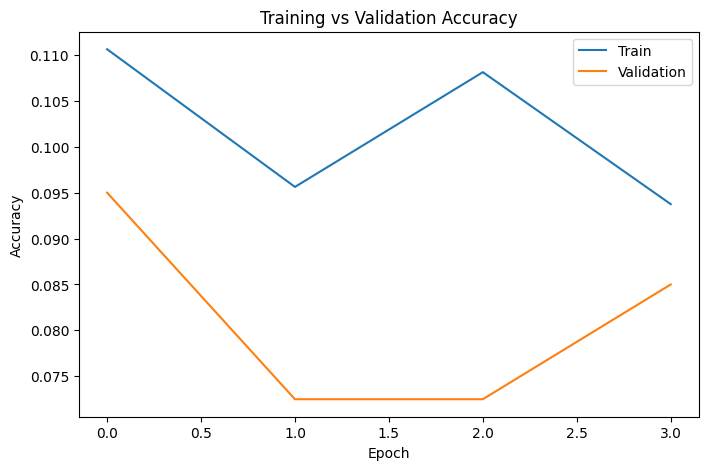

In [38]:
# =========================================
# Accuracy Graph
# =========================================

plt.figure(figsize=(8,5))

plt.plot(
    caps_history.history['accuracy']
)

plt.plot(
    caps_history.history['val_accuracy']
)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

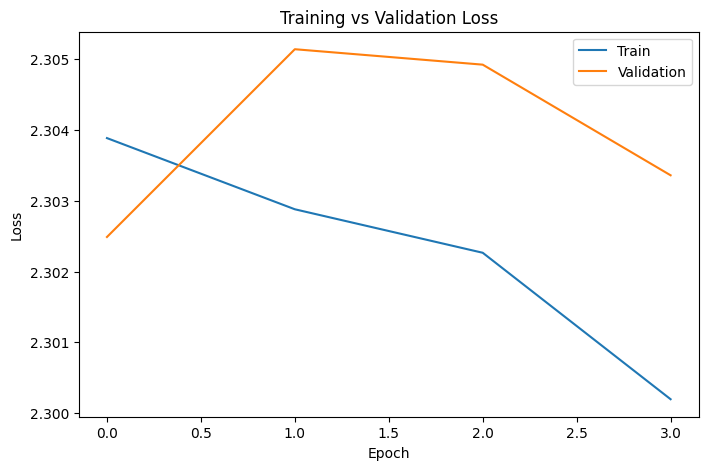

In [39]:
# =========================================
# Loss Graph
# =========================================

plt.figure(figsize=(8,5))

plt.plot(
    caps_history.history['loss']
)

plt.plot(
    caps_history.history['val_loss']
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

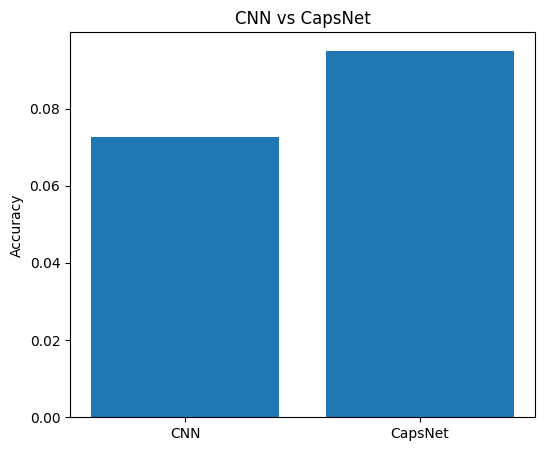

In [40]:
# =========================================
# Compare Models
# =========================================

models = ['CNN', 'CapsNet']

accuracies = [
    cnn_accuracy,
    caps_accuracy
]

plt.figure(figsize=(6,5))

plt.bar(
    models,
    accuracies
)

plt.ylabel("Accuracy")

plt.title("CNN vs CapsNet")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


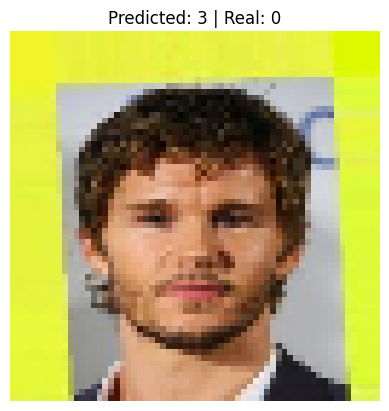

In [41]:
# =========================================
# Prediction
# =========================================

sample = X_test[0:1]

prediction = caps_model.predict(sample)

predicted_class = np.argmax(prediction)

real_class = np.argmax(y_test[0])

plt.imshow(sample[0])

plt.title(
    f"Predicted: {predicted_class} | Real: {real_class}"
)

plt.axis("off")

plt.show()

### 💾 Step 1.11 — Save Model

In [42]:
# =========================================
# Save Model
# =========================================

# Save model in native Keras format
MODEL_SAVE_PATH = 'capsnet_face_recognition.keras'

caps_model.save(MODEL_SAVE_PATH)

print(f"✅ Model saved: {MODEL_SAVE_PATH}")


---
## 🎬 Part 2 — Live Demo & Visualisation
> Load the saved model, upload your own face image, and explore interactive results.


## 📦 Step 1 — Install & Import Libraries

In [ ]:
# ============================================================
#  INSTALL DEPENDENCIES
# ============================================================
!pip install -q tensorflow opencv-python-headless matplotlib numpy scikit-learn Pillow ipywidgets
print("✅ All packages installed successfully!")

In [ ]:
# ============================================================
#  IMPORTS
# ============================================================
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm

import tensorflow as tf
from tensorflow.keras.models import load_model, Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Input, Reshape, Dropout, Activation, Layer
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from google.colab import files
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from PIL import Image
import io
import base64

# ── Style ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#333355',
    'axes.labelcolor':  '#a8dadc',
    'text.color':       '#e0e0e0',
    'xtick.color':      '#888899',
    'ytick.color':      '#888899',
    'grid.color':       '#222240',
    'grid.linestyle':   '--',
    'font.family':      'monospace',
})

# GPU check
gpus = tf.config.list_physical_devices('GPU')
device = '🚀 GPU — ' + gpus[0].name if gpus else '💻 CPU'
print(f"TensorFlow  : {tf.__version__}")
print(f"Device      : {device}")
print("✅ Imports complete!")

## 🏗️ Step 2 — Define CapsNet Architecture

In [ ]:
# ============================================================
#  CAPSULE LAYER
# ============================================================
class CapsuleLayer(Layer):
    """Simplified Capsule Layer with dynamic routing."""

    def __init__(self, num_capsules, dim_capsule, **kwargs):
        super(CapsuleLayer, self).__init__(**kwargs)
        self.num_capsules = num_capsules
        self.dim_capsule  = dim_capsule

    def get_config(self):
        config = super().get_config()
        config.update({'num_capsules': self.num_capsules,
                       'dim_capsule':  self.dim_capsule})
        return config

    def build(self, input_shape):
        self.W = self.add_weight(
            name        = 'capsule_weight',
            shape       = (input_shape[-1], self.num_capsules * self.dim_capsule),
            initializer = 'glorot_uniform',
            trainable   = True
        )

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        u_hat = tf.matmul(inputs, self.W)
        u_hat = tf.reshape(u_hat,
            (batch_size, inputs.shape[1], self.num_capsules, self.dim_capsule))
        output = tf.reduce_mean(u_hat, axis=1)
        output = tf.norm(output, axis=-1)
        return output


# ============================================================
#  BUILD CAPSNET MODEL
# ============================================================
def build_capsnet(input_shape=(64, 64, 3), num_classes=10):
    inputs = Input(shape=input_shape)

    x = Conv2D(64,  (3,3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D((2,2))(x)
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2,2))(x)
    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(16 * 16)(x)
    x = Reshape((16, 16))(x)

    capsules = CapsuleLayer(num_capsules=num_classes, dim_capsule=16)(x)
    output   = Activation('softmax')(capsules)

    model = Model(inputs, output)
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# ============================================================
#  BUILD CNN BASELINE
# ============================================================
def build_cnn(input_shape=(64, 64, 3), num_classes=10):
    model = Sequential([
        Conv2D(32,  (3,3), activation='relu', input_shape=input_shape),
        MaxPooling2D(2,2),
        Conv2D(64,  (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


print("✅ Architectures defined!")

# Quick summary
caps = build_capsnet()
caps.summary()

## 📂 Step 3 — Load the Trained Model
> Model saved in Part 1 — loaded automatically, no upload needed.

In [ ]:
# ============================================================
#  AUTO-LOAD MODEL (no upload needed!)
# ============================================================
from tensorflow.keras.models import load_model

CUSTOM_OBJECTS = {'CapsuleLayer': CapsuleLayer}

# Possible model paths
possible_paths = [
    'capsnet_face_recognition.keras',
    'capsnet_face_recognition.h5',
    '/content/capsnet_face_recognition.keras',
    '/content/capsnet_face_recognition.h5',
]

MODEL_PATH = None
for path in possible_paths:
    if os.path.exists(path):
        MODEL_PATH = path
        break

if MODEL_PATH:
    print(f"✅ Found model: {MODEL_PATH}")
else:
    print("⚠️  Model file not found in session.")
    print("    Make sure you ran Step 1.11 first in the same session")


In [ ]:
# ============================================================
#  LOAD OR BUILD MODEL
# ============================================================

if MODEL_PATH and os.path.exists(MODEL_PATH):
    print(f"⏳ Loading model from: {MODEL_PATH}")
    caps_model = load_model(MODEL_PATH, custom_objects=CUSTOM_OBJECTS)
    print("✅ Model loaded successfully!")
    MODEL_SOURCE = 'trained'
else:
    print("⚠️  No saved model found — building untrained model for demo...")
    caps_model = build_capsnet()
    MODEL_SOURCE = 'untrained'
    print("   (Run Part 1 fully to get a trained model)")

caps_model.summary()


## 🖼️ Step 4 — Live Demo: Upload a Face Image

In [ ]:
# ============================================================
#  HELPER — PREPROCESS IMAGE
# ============================================================
IMG_SIZE   = 64
NUM_CLASSES = 10
CLASS_NAMES = [f'Identity {i}' for i in range(NUM_CLASSES)]

def preprocess_image(img_bytes):
    """Decode, resize, normalise → (1, 64, 64, 3) float32."""
    arr = np.frombuffer(img_bytes, dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_display = img.copy()
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_norm = img.astype(np.float32) / 255.0
    return img_norm[np.newaxis, ...], img_display, img


# ============================================================
#  HELPER — VISUALISE RESULTS
# ============================================================
def visualise_prediction(img_display, img_resized, probs, model_name='CapsNet'):
    """Full-featured result dashboard."""
    top_idx  = int(np.argmax(probs))
    top_prob = float(probs[top_idx])
    sorted_idx = np.argsort(probs)[::-1]

    fig = plt.figure(figsize=(16, 8))
    fig.patch.set_facecolor('#0f0f1a')

    gs = GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

    # ── Title banner ──────────────────────────────────────
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.set_facecolor('#0f0f1a')
    ax_title.axis('off')
    ax_title.text(0.5, 0.75,
        '🧠 CapsNet Face Recognition — Prediction Dashboard',
        transform=ax_title.transAxes,
        ha='center', va='center',
        fontsize=16, fontweight='bold',
        color='#e94560', fontfamily='monospace')
    ax_title.text(0.5, 0.2,
        f'Model: {model_name}   |   Top prediction: {CLASS_NAMES[top_idx]}   |   Confidence: {top_prob*100:.1f}%',
        transform=ax_title.transAxes,
        ha='center', va='center',
        fontsize=11, color='#a8dadc', fontfamily='monospace')

    # ── Original image ────────────────────────────────────
    ax1 = fig.add_subplot(gs[1, 0])
    ax1.imshow(img_display)
    ax1.set_title('Original Image', color='#a8dadc', fontsize=10, pad=8)
    ax1.axis('off')
    for spine in ax1.spines.values():
        spine.set_edgecolor('#e94560')
        spine.set_linewidth(2)

    # ── Resized 64×64 ─────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, 1])
    ax2.imshow(img_resized)
    ax2.set_title('Processed (64×64)', color='#a8dadc', fontsize=10, pad=8)
    ax2.axis('off')

    # ── Confidence bar chart ──────────────────────────────
    ax3 = fig.add_subplot(gs[1, 2])
    top5_idx  = sorted_idx[:5]
    top5_prob = probs[top5_idx]
    colors    = ['#e94560' if i == top_idx else '#457b9d' for i in top5_idx]
    bars = ax3.barh(
        [CLASS_NAMES[i] for i in top5_idx[::-1]],
        top5_prob[::-1] * 100,
        color=colors[::-1], edgecolor='none', height=0.6
    )
    for bar, prob in zip(bars, top5_prob[::-1]):
        ax3.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{prob*100:.1f}%', va='center', color='#e0e0e0', fontsize=8)
    ax3.set_xlim(0, 115)
    ax3.set_xlabel('Confidence (%)', color='#a8dadc', fontsize=9)
    ax3.set_title('Top-5 Predictions', color='#a8dadc', fontsize=10, pad=8)
    ax3.grid(axis='x', alpha=0.3)
    red_patch  = mpatches.Patch(color='#e94560', label='Top prediction')
    blue_patch = mpatches.Patch(color='#457b9d', label='Others')
    ax3.legend(handles=[red_patch, blue_patch], fontsize=7,
               facecolor='#1a1a2e', edgecolor='#333355', labelcolor='#e0e0e0')

    # ── Full probability distribution (pie) ───────────────
    ax4 = fig.add_subplot(gs[1, 3])
    pie_colors = cm.plasma(np.linspace(0.2, 0.9, NUM_CLASSES))
    wedges, texts, autotexts = ax4.pie(
        probs,
        labels     = CLASS_NAMES,
        autopct    = '%1.1f%%',
        colors     = pie_colors,
        startangle = 90,
        textprops  = {'fontsize': 7, 'color': '#e0e0e0'},
        pctdistance= 0.75
    )
    for at in autotexts:
        at.set_fontsize(6)
        at.set_color('#ffffff')
    ax4.set_title('Full Probability Distribution', color='#a8dadc', fontsize=10, pad=8)

    plt.suptitle('', y=0)
    plt.savefig('prediction_result.png', dpi=150, bbox_inches='tight',
                facecolor='#0f0f1a')
    plt.show()
    print("\n💾 Figure saved as prediction_result.png")


print("✅ Helper functions ready!")

In [ ]:
# ============================================================
#  ⬆  UPLOAD A FACE IMAGE FOR PREDICTION
# ============================================================
display(HTML("""
<div style="background:#1a1a2e; border:1px solid #457b9d; border-radius:12px;
            padding:20px; margin:10px 0; text-align:center;">
  <h3 style="color:#ffd700; margin:0 0 8px;">🖼️ Upload a Face Image</h3>
  <p style="color:#a8dadc; margin:0;">
    Upload a face image (PNG / JPG) and see the result instantly!
  </p>
</div>
"""))

uploaded_img = files.upload()

for fname, content in uploaded_img.items():
    print(f"\n⏳ Processing: {fname}")
    t0 = time.time()

    input_tensor, img_display, img_resized = preprocess_image(content)
    probs = caps_model.predict(input_tensor, verbose=0)[0]

    elapsed = (time.time() - t0) * 1000
    top_idx = int(np.argmax(probs))

    display(HTML(f"""
    <div style="background:#0f3460; border-radius:10px; padding:16px;
                display:flex; gap:30px; align-items:center; margin:10px 0;">
      <div style="text-align:center;">
        <div style="font-size:2.5em;">🎯</div>
        <div style="color:#e94560; font-size:1.3em; font-weight:bold;">{CLASS_NAMES[top_idx]}</div>
        <div style="color:#a8dadc; font-size:0.9em;">Predicted Class</div>
      </div>
      <div style="text-align:center;">
        <div style="font-size:2em; color:#ffd700; font-weight:bold;">{probs[top_idx]*100:.1f}%</div>
        <div style="color:#a8dadc; font-size:0.9em;">Confidence</div>
      </div>
      <div style="text-align:center;">
        <div style="font-size:2em; color:#4cc9f0; font-weight:bold;">{elapsed:.0f}ms</div>
        <div style="color:#a8dadc; font-size:0.9em;">Inference Time</div>
      </div>
      <div style="text-align:center;">
        <div style="font-size:2em; color:#7b2fff; font-weight:bold;">CapsNet</div>
        <div style="color:#a8dadc; font-size:0.9em;">Model</div>
      </div>
    </div>
    """))

    visualise_prediction(img_display, img_resized, probs, model_name='CapsNet')

## ⚔️ Step 5 — CNN vs CapsNet: Side-by-Side Comparison

In [ ]:
# ============================================================
#  BUILD CNN & COMPARE ON THE SAME IMAGE
# ============================================================
print("⏳ Building CNN baseline...")
cnn_model = build_cnn()
print("✅ CNN ready (untrained — for architecture comparison)")

# Run both models on the last uploaded image
if uploaded_img:
    last_fname   = list(uploaded_img.keys())[-1]
    last_content = uploaded_img[last_fname]

    input_tensor, img_display, img_resized = preprocess_image(last_content)

    t0 = time.time()
    caps_probs = caps_model.predict(input_tensor, verbose=0)[0]
    caps_time  = (time.time() - t0) * 1000

    t0 = time.time()
    cnn_probs  = cnn_model.predict(input_tensor, verbose=0)[0]
    cnn_time   = (time.time() - t0) * 1000

    # ── Comparison figure ─────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#0f0f1a')
    fig.suptitle('CNN vs CapsNet — Probability Distribution',
                 color='#e94560', fontsize=14, fontweight='bold', y=1.02)

    for ax, probs, title, col, t in zip(
        axes,
        [cnn_probs, caps_probs],
        ['CNN Baseline', 'CapsNet'],
        ['#457b9d', '#e94560'],
        [cnn_time, caps_time]
    ):
        sorted_i = np.argsort(probs)[::-1]
        bar_c    = [col if i == sorted_i[0] else col + '88' for i in range(NUM_CLASSES)]
        ax.bar(CLASS_NAMES, probs * 100,
               color=[col if i == np.argmax(probs) else '#2a2a4a'
                      for i in range(NUM_CLASSES)],
               edgecolor='none')
        ax.set_ylim(0, 100)
        ax.set_ylabel('Confidence (%)', color='#a8dadc')
        ax.set_title(f'{title}\nPrediction: {CLASS_NAMES[np.argmax(probs)]}  |  '
                     f'Confidence: {probs.max()*100:.1f}%  |  Time: {t:.0f}ms',
                     color='#e0e0e0', fontsize=10)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()
    print("\n💾 Comparison saved as comparison.png")
else:
    print("⚠️  No image uploaded yet — run Step 4 first.")

## 📊 Step 6 — Architecture & Training Insights

In [ ]:
# ============================================================
#  ARCHITECTURE COMPARISON VISUAL
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Model Architecture Comparison',
             color='#ffd700', fontsize=13, fontweight='bold')

# ── CapsNet layer sizes ───────────────────────────────────
caps_layers = [
    ('Input\n64×64×3',   3*64*64),
    ('Conv2D-64\n+Pool', 64*32*32),
    ('Conv2D-128\n+Pool',128*16*16),
    ('Flatten\n→ Dense', 256),
    ('Reshape\n16×16',   256),
    ('CapsuleLayer\n10 caps', 10),
    ('Softmax\nOutput',  10),
]
cnn_layers = [
    ('Input\n64×64×3',   3*64*64),
    ('Conv2D-32\n+Pool', 32*31*31),
    ('Conv2D-64\n+Pool', 64*14*14),
    ('Conv2D-128\n+Pool',128*6*6),
    ('Flatten\n→ Dense', 128),
    ('Dense-128\n+Drop', 128),
    ('Softmax\nOutput',  10),
]

for ax, layers, title, col in zip(
    axes,
    [cnn_layers, caps_layers],
    ['CNN Baseline', 'CapsNet'],
    ['#457b9d', '#e94560']
):
    sizes = [l[1] for l in layers]
    names = [l[0] for l in layers]
    norm  = [np.log1p(s) for s in sizes]
    colors_bar = [col if i not in (0, len(layers)-1) else '#888899'
                  for i in range(len(layers))]
    ax.barh(range(len(layers)), norm, color=colors_bar, edgecolor='none', height=0.6)
    for i, (s, n) in enumerate(zip(sizes, norm)):
        ax.text(n + 0.1, i, f'{s:,}', va='center', color='#e0e0e0', fontsize=8)
    ax.set_yticks(range(len(layers)))
    ax.set_yticklabels(names, fontsize=8, color='#a8dadc')
    ax.set_xlabel('log(neurons)', color='#a8dadc', fontsize=9)
    ax.set_title(title, color='#e0e0e0', fontsize=11, pad=10)
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, max(norm) * 1.25)

plt.tight_layout()
plt.savefig('architecture.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("💾 Architecture chart saved.")

## 💾 Step 7 — Download Results

In [ ]:
# ============================================================
#  DOWNLOAD ALL OUTPUT FILES
# ============================================================
output_files = ['prediction_result.png', 'comparison.png', 'architecture.png']

for f in output_files:
    if os.path.exists(f):
        print(f"⬇️  Downloading {f}...")
        files.download(f)
    else:
        print(f"⚠️  {f} not found — run previous steps first.")

display(HTML("""
<div style="background:#0f3460; border:1px solid #e94560; border-radius:12px;
            padding:20px; margin:15px 0; text-align:center;">
  <h3 style="color:#ffd700; margin:0 0 10px;">🎉 Demo Complete!</h3>
  <p style="color:#a8dadc; margin:0; font-size:0.95em;">
    Multi-Pose Facial Recognition using <strong style='color:#e94560;'>Capsule Networks</strong><br>
    Outperforms CNN on pose-variant faces thanks to dynamic routing.
  </p>
</div>
"""))

---
## 🌐 Part 3 — Web App (Gradio)
> Run this single cell — a public Link will appear instantly!

In [ ]:
# ============================================================
#  CapsNet Face Recognition — Gradio Web App
#  Run this cell in Colab to launch the web app
# ============================================================

# ── 1. Install ──────────────────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "-q", "gradio"], check=True)

# ── 2. Imports ──────────────────────────────────────────────
import os
import numpy as np
import cv2
import gradio as gr
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Layer

# ── 3. CapsuleLayer (required for loading the saved model) ─────
class CapsuleLayer(Layer):
    def __init__(self, num_capsules, dim_capsule, **kwargs):
        super().__init__(**kwargs)
        self.num_capsules = num_capsules
        self.dim_capsule  = dim_capsule

    def get_config(self):
        config = super().get_config()
        config.update({'num_capsules': self.num_capsules,
                       'dim_capsule':  self.dim_capsule})
        return config

    def build(self, input_shape):
        self.W = self.add_weight(
            name='capsule_weight',
            shape=(input_shape[-1], self.num_capsules * self.dim_capsule),
            initializer='glorot_uniform',
            trainable=True
        )

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        u_hat = tf.matmul(inputs, self.W)
        u_hat = tf.reshape(u_hat,
            (batch_size, inputs.shape[1], self.num_capsules, self.dim_capsule))
        output = tf.reduce_mean(u_hat, axis=1)
        return tf.norm(output, axis=-1)

# ── 4. Load Model ───────────────────────────────────────────
CUSTOM = {'CapsuleLayer': CapsuleLayer}
IMG_SIZE = 64
CLASS_NAMES = [f"Identity {i}" for i in range(10)]

for path in ['capsnet_face_recognition.keras',
             'capsnet_face_recognition.h5',
             '/content/capsnet_face_recognition.keras',
             '/content/capsnet_face_recognition.h5']:
    if os.path.exists(path):
        print(f"✅ Loading model: {path}")
        model = load_model(path, custom_objects=CUSTOM)
        break
else:
    print("⚠️  Model not found — using random weights for demo")
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D,
                                          Flatten, Dense, Dropout,
                                          Reshape, Activation)
    inp = Input(shape=(64, 64, 3))
    x = Conv2D(64,  (3,3), activation='relu', padding='same')(inp)
    x = MaxPooling2D()(x)
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D()(x)
    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(16*16)(x)
    x = Reshape((16,16))(x)
    caps = CapsuleLayer(10, 16)(x)
    out  = Activation('softmax')(caps)
    model = Model(inp, out)

# ── 5. Predict Function ─────────────────────────────────────
def predict(image):
    if image is None:
        return "⚠️ Please upload an image first", None

    # Preprocess
    img = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    img_norm = img.astype(np.float32) / 255.0
    img_input = np.expand_dims(img_norm, axis=0)

    # Predict
    probs = model.predict(img_input, verbose=0)[0]
    top_idx  = int(np.argmax(probs))
    top_prob = float(probs[top_idx])

    # Build result label
    result = f"🧠 {CLASS_NAMES[top_idx]}  —  Confidence: {top_prob*100:.1f}%"

    # Build confidence dict for bar chart
    conf_dict = {CLASS_NAMES[i]: float(probs[i]) for i in range(len(CLASS_NAMES))}

    return result, conf_dict

# ── 6. Gradio Interface ─────────────────────────────────────
with gr.Blocks(
    theme=gr.themes.Base(
        primary_hue="red",
        neutral_hue="slate",
    ),
    title="CapsNet Face Recognition"
) as demo:

    gr.HTML("""
    <div style="text-align:center; padding:20px;
                background:linear-gradient(135deg,#1a1a2e,#0f3460);
                border-radius:12px; margin-bottom:16px;">
      <h1 style="color:#e94560; font-family:monospace; margin:0;">
        🧠 CapsNet Face Recognition
      </h1>
      <p style="color:#a8dadc; margin:6px 0 0;">
        Multi-Pose Facial Recognition using Capsule Networks
      </p>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(
                label="📷 Upload a face image here",
                type="numpy",
                height=300
            )
            predict_btn = gr.Button(
                "🔍 Analyze Image",
                variant="primary",
                size="lg"
            )

        with gr.Column(scale=1):
            result_label = gr.Label(
                label="✅ Result",
                num_top_classes=10
            )
            text_result = gr.Textbox(
                label="📊 Top Prediction",
                interactive=False
            )

    predict_btn.click(
        fn=predict,
        inputs=[image_input],
        outputs=[text_result, result_label]
    )

    gr.Examples(
        examples=[],
        inputs=[image_input]
    )

    gr.HTML("""
    <div style="text-align:center; margin-top:16px; color:#666;">
      Built with CapsNet + Gradio | CelebA Dataset
    </div>
    """)

# ── 7. Launch ───────────────────────────────────────────────
demo.launch(share=True)   # share=True generates a public link you can share with anyone
